# Trabalho Final - Feature Engineering

Questão: Utilizando todos os conhecimentos apresentados no decorrer da disciplina, utilize o dataset Quantum Finance para manipular os dados que futuramente serão utilizados por um modelo de Machine Learning para realizar predições a respeito do Score. Deverão ser utilizados pelo menos 15 técnicas apresentas durante a disciplina. 

O resultado da entrega deverá ser um arquivo python com toda a manipulação de dados realizada. O arquivo python deverá conter comentários para facilitar o entendimento no código, de preferência, o arquivo poderá ser entregue em formato .ipynb (Jupyter Notebook).

In [1]:
# Importando as bibliotecas

import pandas as pd              
import numpy as np              

from sklearn.model_selection import train_test_split   
from sklearn.preprocessing import StandardScaler        
from sklearn.impute import SimpleImputer              
from sklearn.linear_model import LogisticRegression    
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import KBinsDiscretizer 
from sklearn.cluster import KMeans


import matplotlib.pyplot as plt  
import seaborn as sns

In [2]:
# carregando os dados:

df = pd.read_csv('Base_ScoreCredito_QuantumFinance.csv', sep = ';')

# EDA - Análise Exploratória dos Dados


In [3]:
df.head()

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
0,708082083,45,F,casado,graduacao,3,40,1,"40,089665024322",3,0,0,1,1,778
1,708083283,58,M,solteiro,ensino fundam,0,44,1,"66,557645274838",3,0,0,1,0,"276,3"
2,708084558,46,M,divorciado,doutorado,3,35,1,"123,68182089138",6,0,0,1,1,401
3,708085458,34,F,solteiro,mestrado,0,22,1,"19,7159343168329",6,0,0,1,0,"347,4"
4,708086958,49,F,casado,mestrado,2,36,0,0,3,1,437,1,2,476


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   10127 non-null  int64
 1   idade                10127 non-null  int64
 2   sexo                 10127 non-null  str  
 3   estado_civil         10127 non-null  str  
 4   escola               10127 non-null  str  
 5   Qte_dependentes      10127 non-null  int64
 6   tempo_ultimoservico  10127 non-null  int64
 7   trabalha             10127 non-null  int64
 8   vl_salario_mil       10127 non-null  str  
 9   reg_moradia          10127 non-null  int64
 10  casa_propria         10127 non-null  int64
 11  vl_imovel_em_mil     10127 non-null  int64
 12  Qte_cartoes          10127 non-null  int64
 13  Qte_carros           10127 non-null  int64
 14  SCORE_CREDITO        10127 non-null  str  
dtypes: int64(10), str(5)
memory usage: 1.2 MB


In [5]:
# Corrigimos a coluna vl_salario_mil para numérico

df['vl_salario_mil'] # Por estar separado em vírgulas, o python entendeu que a coluna é uma string

df['vl_salario_mil'] = df['vl_salario_mil'].str.replace(',', '.').astype(np.float64) # Corrigimos isso trocando a vírgula pelo ponto e setando a coluna como float64

# Faremos também o mesmo processo para a variável target SCORE_CREDITO

df['SCORE_CREDITO'] = df['SCORE_CREDITO'].str.replace(',', '.').astype(np.float64)

In [6]:
# Também vamos tratar a coluna vl_imovel_em_mil, já que temos várias entradas zeradas. Vamos tratar isso posteriormente no pré-processamento

pd.crosstab(df['casa_propria'], df['vl_imovel_em_mil'] == 0) # Confirmando se a relação é verdadeira

vl_imovel_em_mil,False,True
casa_propria,,
0,0,6558
1,3569,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10127 non-null  int64  
 1   idade                10127 non-null  int64  
 2   sexo                 10127 non-null  str    
 3   estado_civil         10127 non-null  str    
 4   escola               10127 non-null  str    
 5   Qte_dependentes      10127 non-null  int64  
 6   tempo_ultimoservico  10127 non-null  int64  
 7   trabalha             10127 non-null  int64  
 8   vl_salario_mil       10127 non-null  float64
 9   reg_moradia          10127 non-null  int64  
 10  casa_propria         10127 non-null  int64  
 11  vl_imovel_em_mil     10127 non-null  int64  
 12  Qte_cartoes          10127 non-null  int64  
 13  Qte_carros           10127 non-null  int64  
 14  SCORE_CREDITO        10127 non-null  float64
dtypes: float64(2), int64(10), str(3)
memory usage: 

In [8]:
df.describe()

,id,idade,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,1.547447,34.133208,0.911919,70.209002,3.783450,0.352424,208.999111,1.083638,0.623383,469.500364
std,3.690378e+07,8.016814,1.489079,8.221428,0.283427,55.567032,1.580486,0.477749,378.495229,0.333784,0.569796,133.814653
min,7.080821e+08,26.000000,0.000000,7.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,162.000000
25%,7.130368e+08,41.000000,0.000000,30.000000,1.000000,21.330536,3.000000,0.000000,0.000000,1.000000,0.000000,375.000000
50%,7.179264e+08,46.000000,1.000000,34.000000,1.000000,66.486331,4.000000,0.000000,0.000000,1.000000,1.000000,449.600000
75%,7.731435e+08,52.000000,3.000000,39.000000,1.000000,107.544225,5.000000,1.000000,289.000000,1.000000,1.000000,540.900000
max,8.283431e+08,73.000000,5.000000,57.000000,1.000000,233.301793,6.000000,1.000000,1800.000000,4.000000,2.000000,979.650000


# Separação dos dados - Treino e Teste

In [9]:
# Antes de realizar as manipulações, separamos os dados de treino e teste para evitar vazamento de dados (data leakage)

X = df.drop(columns=['SCORE_CREDITO'])
y = df['SCORE_CREDITO']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

# Pré-processamento

In [10]:
# Inicialmente, verificamos se temos dados faltantes no dataset

print(f'Dados faltantes X treino: {X_train.isna().sum()}')
print(f'Dados faltantes X teste: {X_test.isna().sum()}')
print(f'Dados faltantes y treino: {y_train.isna().sum()}')
print(f'Dados faltantes y teste: {y_test.isna().sum()}')



Dados faltantes X treino: id                     0
idade                  0
sexo                   0
estado_civil           0
escola                 0
Qte_dependentes        0
tempo_ultimoservico    0
trabalha               0
vl_salario_mil         0
reg_moradia            0
casa_propria           0
vl_imovel_em_mil       0
Qte_cartoes            0
Qte_carros             0
dtype: int64
Dados faltantes X teste: id                     0
idade                  0
sexo                   0
estado_civil           0
escola                 0
Qte_dependentes        0
tempo_ultimoservico    0
trabalha               0
vl_salario_mil         0
reg_moradia            0
casa_propria           0
vl_imovel_em_mil       0
Qte_cartoes            0
Qte_carros             0
dtype: int64
Dados faltantes y treino: 0
Dados faltantes y teste: 0


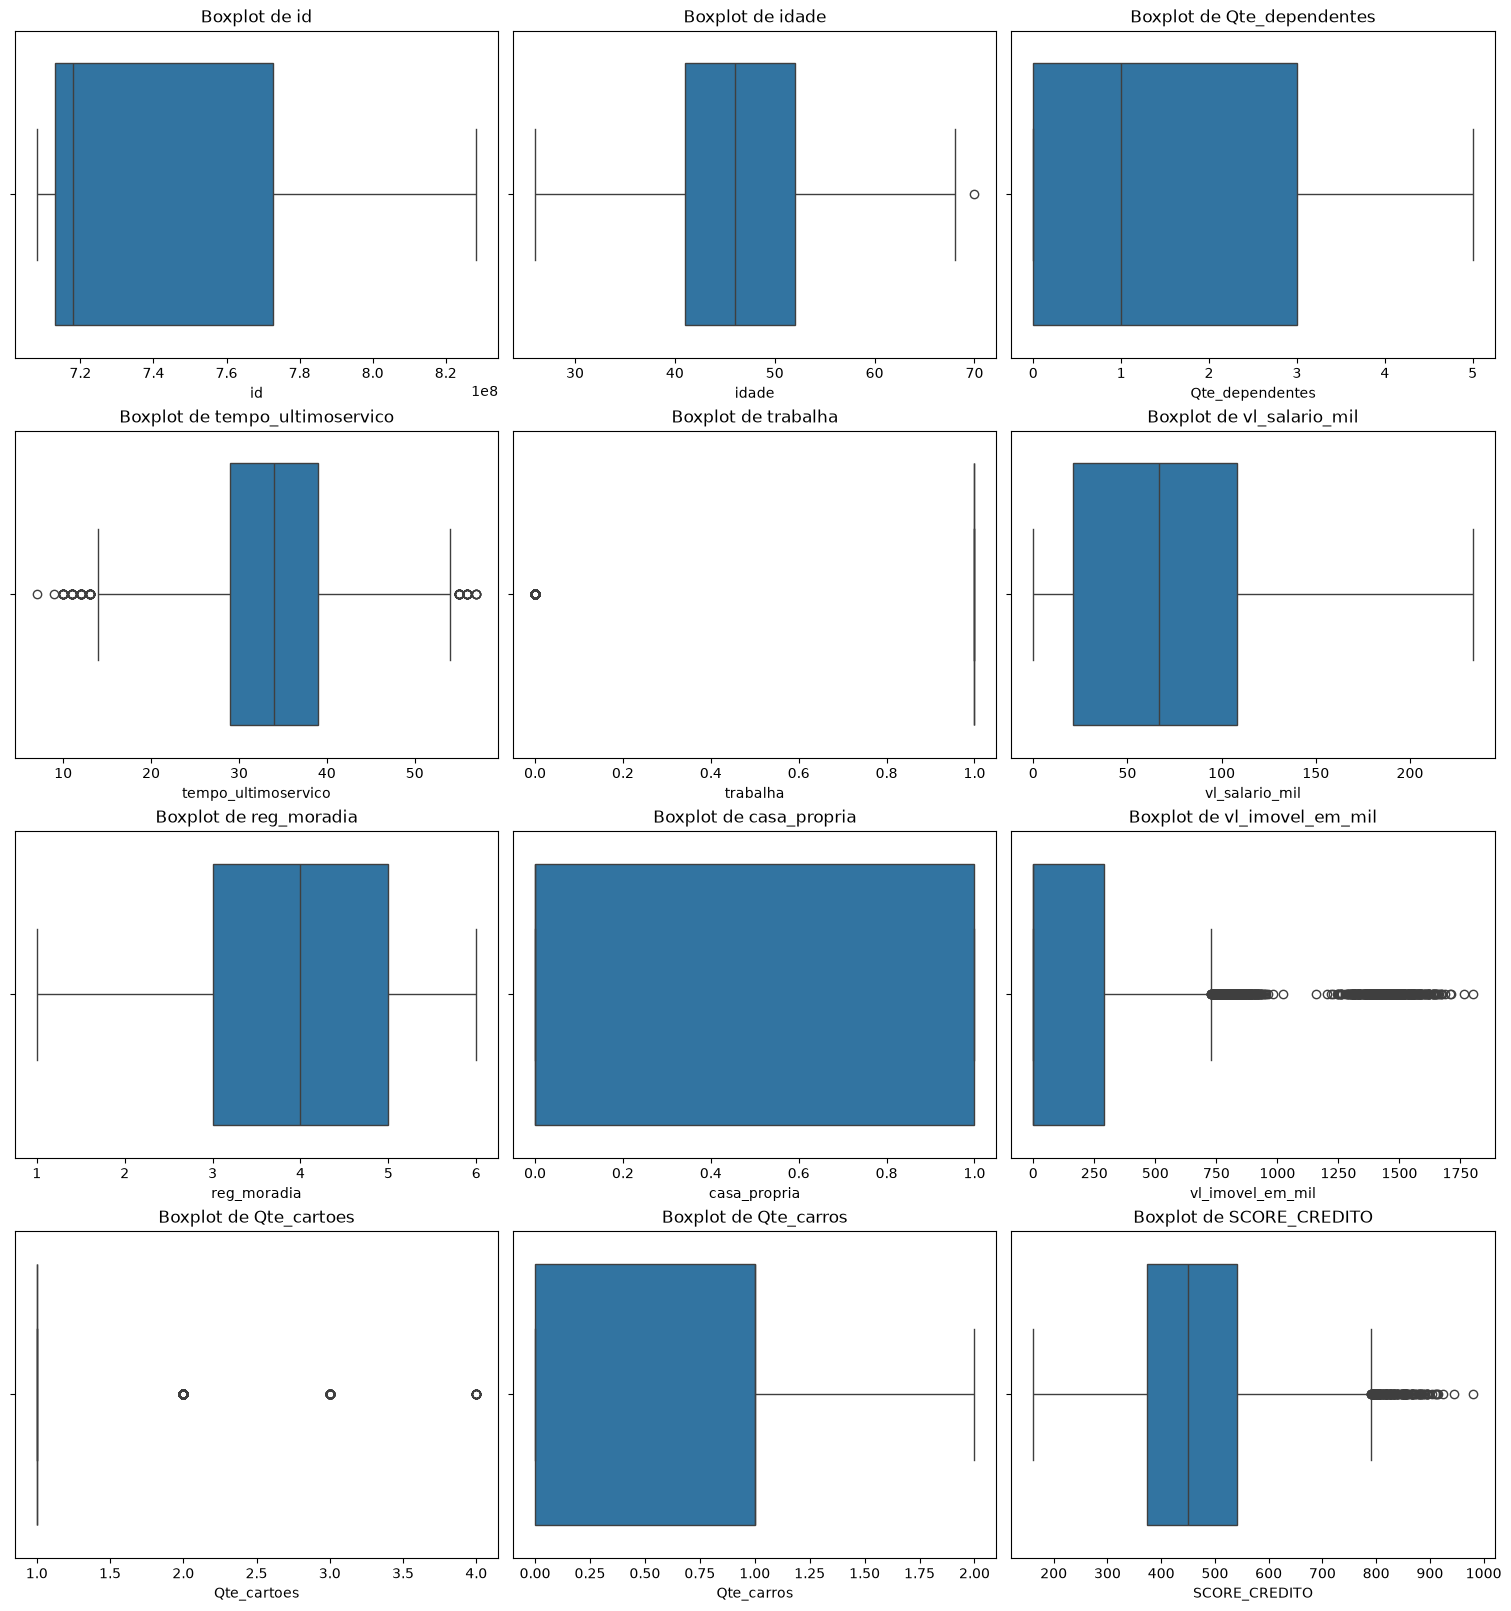

In [11]:
# Feitas as verificações por dados faltantes, vamos fazer o tratamento de outliers nas colunas numéricas

# Recriação de DataFrames completos para facilitação do tratamento:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# Selecionamos apenas as colunas numéricas do dataset de treino para esse tratamento, vamos aplicar os limites de outliers no dataset de teste depois
df_train_numeric = df_train.select_dtypes(include=['int64', 'float64'])

# Plotamos os boxplots das colunas numéricas para averiguar seu comportamento e presença de outliers
import math

colunas = df_train_numeric.columns
n = len(colunas)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), layout='constrained')
axes = axes.flatten()

for i, coluna in enumerate(colunas):
    sns.boxplot(data=df_train, x=coluna, ax=axes[i])
    axes[i].set_title(f'Boxplot de {coluna}')

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [12]:
# id, casa_propria e trabalha não entram no tratamento de outliers
# (identificador e binárias), mas permanecem como features do modelo.
# Por isso não são dropadas aqui — apenas ficam fora das listas abaixo.

Para o tratamento dos outliers, foi decidido tratar os dados de duas formas.

In [13]:
# IQR, para colunas com poucos casos de outliers ou outliers simétricos em ambas as pontas, no caso de idade e tempo_ultimoservico:

# Analisar outliers apenas nos dados de treino
def analyze_outliers(df):
    outlier_counts = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_counts[col] = len(outliers)
    
    return pd.Series(outlier_counts).sort_values(ascending=False)

# Analisar outliers apenas nos dados de treino
outlier_analysis = analyze_outliers(df_train[['idade', 'tempo_ultimoservico']])
print("Outliers por coluna (dados de treino):")
print(outlier_analysis)

Outliers por coluna (dados de treino):
tempo_ultimoservico    116
idade                    1
dtype: int64


In [14]:
# Função para calcular os limites de outliers baseados apenas nos dados de treino
def get_outlier_bounds(df_train, columns_to_clean=None):
    """
    Calcula os limites de outliers baseados apenas nos dados de treino
    """
    if columns_to_clean is None:
        columns_to_clean = ['idade', 'tempo_ultimoservico']
    
    bounds = {}
    
    for col in columns_to_clean:
        if col in df_train.columns:
            Q1 = df_train[col].quantile(0.25)
            Q3 = df_train[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            bounds[col] = (lower_bound, upper_bound)
    
    return bounds

# Função para aplicar remoção de outliers usando limites pré-definidos
def remove_outliers_with_bounds(df, bounds):
    """Remove outliers usando limites pré-calculados, preservando X e y alinhados"""
    mask_ok = pd.Series(True, index=df.index)
    for col, (lower_bound, upper_bound) in bounds.items():
        if col in df.columns:
            mask_ok &= df[col].between(lower_bound, upper_bound)

    print(f'Removidas {(~mask_ok).sum()} de {len(df)} linhas '
          f'({(~mask_ok).mean()*100:.2f}%)')
    return df[mask_ok].copy()

# Calcular limites baseados apenas nos dados de treino
bounds_iqr = get_outlier_bounds(df_train, ['idade', 'tempo_ultimoservico'])

# Remoção por IQR aplicada SOMENTE no treino (df completo, X e y alinhados)
print("=== TRATAMENTO DOS DADOS DE TREINO (IQR) ===")
df_train = remove_outliers_with_bounds(df_train, bounds_iqr)

=== TRATAMENTO DOS DADOS DE TREINO (IQR) ===
Removidas 117 de 7088 linhas (1.65%)


In [15]:
# Limiar por percentil: capping preserva as linhas (cauda longa demais para remoção)

# --- vl_salario_mil: capping padrão sobre toda a coluna ---
lower_sal = df_train['vl_salario_mil'].quantile(0.01)
upper_sal = df_train['vl_salario_mil'].quantile(0.99)

df_train['vl_salario_mil'] = df_train['vl_salario_mil'].clip(lower_sal, upper_sal)
df_test['vl_salario_mil']  = df_test['vl_salario_mil'].clip(lower_sal, upper_sal)

# --- vl_imovel_em_mil: os zeros indicam ausência de imóvel (redundante com casa_propria),
# não valor baixo. Limites calculados e aplicados apenas sobre quem possui imóvel. ---
com_imovel_train = df_train['vl_imovel_em_mil'] > 0
com_imovel_test  = df_test['vl_imovel_em_mil'] > 0

lower_imv = round(df_train.loc[com_imovel_train, 'vl_imovel_em_mil'].quantile(0.01))
upper_imv = round(df_train.loc[com_imovel_train, 'vl_imovel_em_mil'].quantile(0.99))

df_train.loc[com_imovel_train, 'vl_imovel_em_mil'] = (
    df_train.loc[com_imovel_train, 'vl_imovel_em_mil'].clip(lower_imv, upper_imv)
)
df_test.loc[com_imovel_test, 'vl_imovel_em_mil'] = (
    df_test.loc[com_imovel_test, 'vl_imovel_em_mil'].clip(lower_imv, upper_imv)
)

print(f'Limites vl_salario_mil: {lower_sal:.2f} a {upper_sal:.2f}')
print(f'Limites vl_imovel_em_mil (só com imóvel): {lower_imv:.2f} a {upper_imv:.2f}')

# Reatribuição de X e y após os tratamentos
X_train = df_train.drop(columns=['SCORE_CREDITO', 'id'])
y_train = df_train['SCORE_CREDITO']
X_test  = df_test.drop(columns=['SCORE_CREDITO', 'id'])
y_test  = df_test['SCORE_CREDITO']

Limites vl_salario_mil: 0.00 a 205.43
Limites vl_imovel_em_mil (só com imóvel): 156.00 a 1617.00


In [16]:
# Feito o tratamento de outliers, vamos verificar a presença de dados duplicados no df de treino:

duplicates_train = df_train.duplicated()
num_duplicates_train = duplicates_train.sum()
print(f"Número de registros duplicados nos dados de treino: {num_duplicates_train}")


Número de registros duplicados nos dados de treino: 0


Verificamos a presença de dados faltantes e duplicados, além de tratar os outliers, agora vamos iniciar o tratamento dos dados numéricos e categóricos.

# Tratamento de dados numéricos

Aplicamos os três métodos de binning da disciplina, cada um na variável cuja distribuição o favorece:

idade — Equal Width Binning: distribuição aproximadamente simétrica e faixas etárias de largura fixa possuem significado convencional, facilitando a interpretação.

vl_salario_mil — Equal Frequency Binning: distribuição assimétrica à direita, na qual intervalos de largura fixa gerariam faixas muito desiguais em número de clientes; faixas por quantil refletem a segmentação de renda usada no setor financeiro.

vl_imovel_em_mil — K-Means: distribuição irregular e sem pontos de corte naturais, cabendo ao algoritmo identificar os agrupamentos de valor existentes nos dados.

O objetivo é permitir que o modelo capture relações não-lineares entre essas variáveis e o score, que a escala contínua não expressa em modelos lineares. As colunas originais são mantidas, deixando que a seleção de features determine qual representação contribui mais. Os parâmetros (bordas e centroides) são estimados apenas no treino e aplicados ao teste.

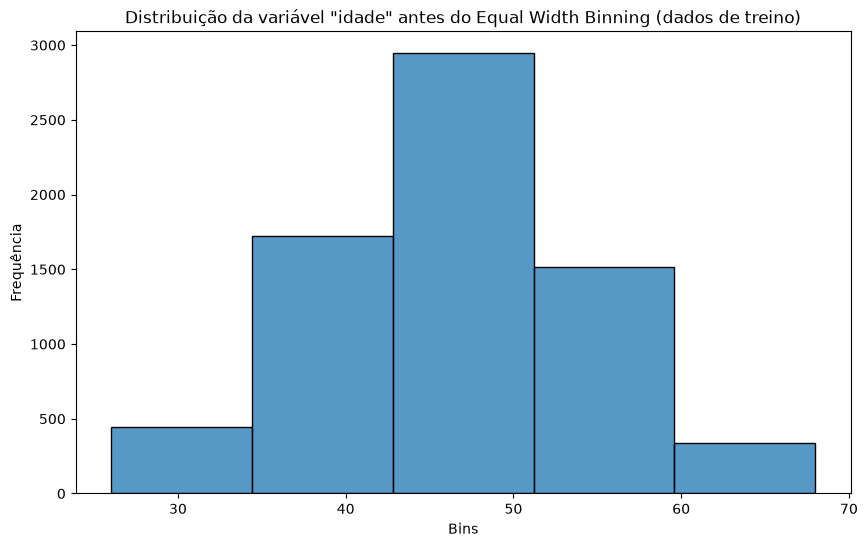

In [17]:
# Plotando a distribuição dos dados de idade:
plt.figure(figsize=(10, 6))
sns.histplot(X_train['idade'], bins=5, kde=False)
plt.title('Distribuição da variável "idade" antes do Equal Width Binning (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

In [18]:
# Agora, vamos fazer a discreção de idade:
equal_frequency_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_train['idade'] = equal_frequency_discretizer.fit_transform(X_train[['idade']])
X_test['idade'] = equal_frequency_discretizer.transform(X_test[['idade']])

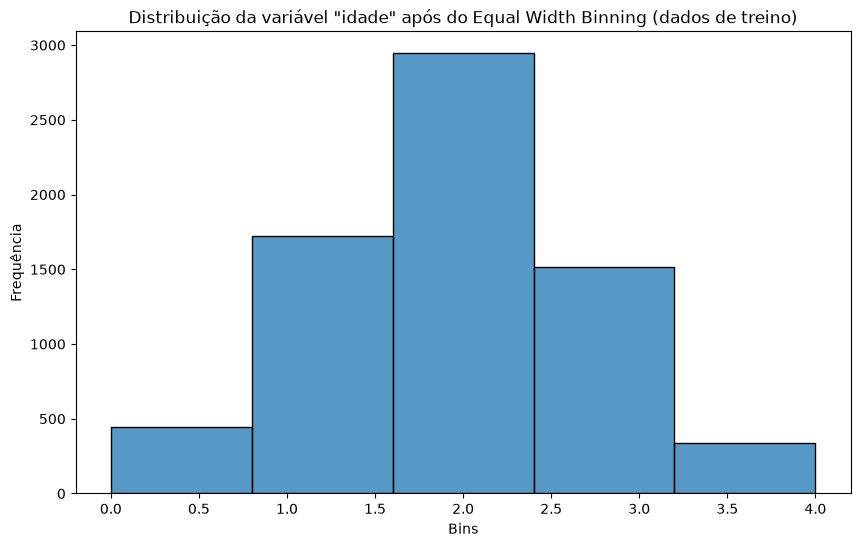

In [19]:
# Plotando a distribuição dos dados de idade:
plt.figure(figsize=(10, 6))
sns.histplot(X_train['idade'], bins=5, kde=False)
plt.title('Distribuição da variável "idade" após do Equal Width Binning (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

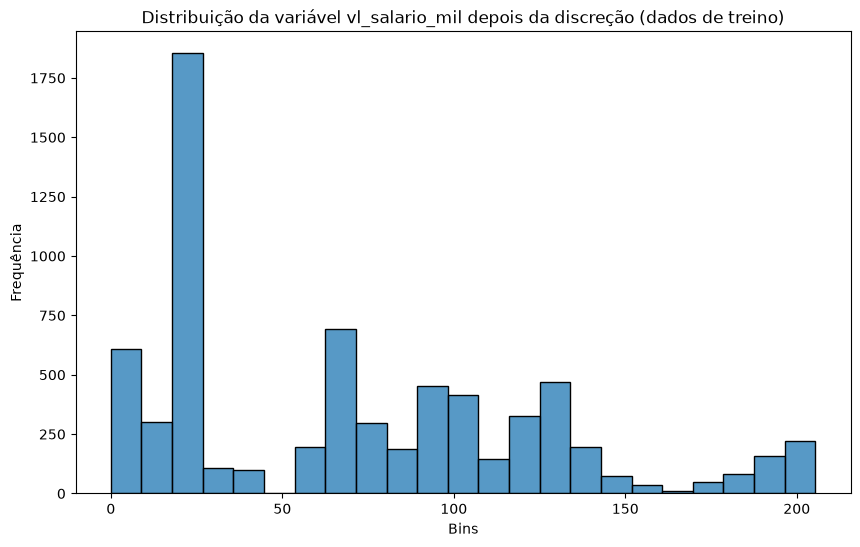

In [20]:
# Analisamos também a distribuição dos dados de vl_salario_mil:

plt.figure(figsize=(10, 6))
sns.histplot(X_train['vl_salario_mil'], kde=False)
plt.title('Distribuição da variável vl_salario_mil depois da discreção (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

In [21]:
# Agora, partimos para a discreção de vl_salario_mil com Equal Frequency Binning:

equal_frequency_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
X_train['vl_salario_mil'] = equal_frequency_discretizer.fit_transform(X_train[['vl_salario_mil']])
X_test['vl_salario_mil'] = equal_frequency_discretizer.transform(X_test[['vl_salario_mil']])

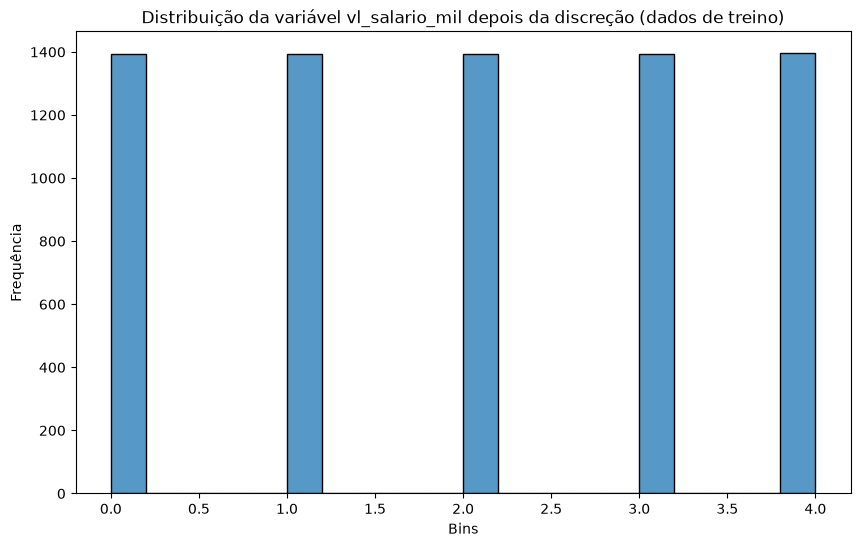

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(X_train['vl_salario_mil'], kde=False)
plt.title('Distribuição da variável vl_salario_mil depois da discreção (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

<Axes: xlabel='vl_imovel_em_mil', ylabel='Count'>

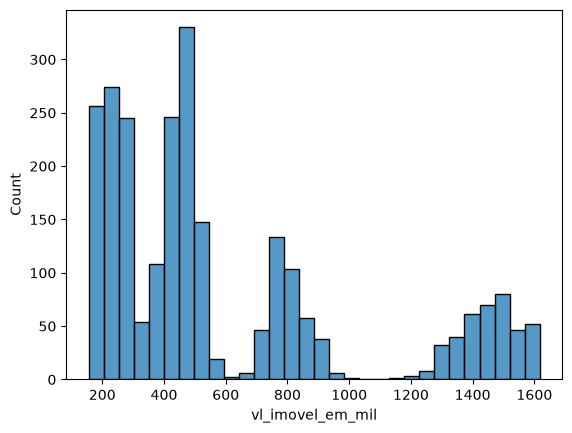

In [23]:
# Por fim, vamos fazer a análise de vl_imovel_mil com K-means:

sns.histplot(df_train.loc[df_train['vl_imovel_em_mil'] > 0, 'vl_imovel_em_mil'], bins=30)

In [24]:
# K-Means ajustado apenas sobre clientes com imóvel — os zeros indicam ausência,
# não valor baixo, e consumiriam um centroide inteiro se incluídos.
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)

# Categoria 0 reservada para "sem imóvel"
X_train['vl_imovel_em_mil_kmeans'] = 0
X_test['vl_imovel_em_mil_kmeans'] = 0

mask_tr = X_train['vl_imovel_em_mil'] > 0
mask_te = X_test['vl_imovel_em_mil'] > 0

# Clusters 1 a 4 para quem possui imóvel
X_train.loc[mask_tr, 'vl_imovel_em_mil_kmeans'] = kmeans.fit_predict(
    X_train.loc[mask_tr, ['vl_imovel_em_mil']]
) + 1

X_test.loc[mask_te, 'vl_imovel_em_mil_kmeans'] = kmeans.predict(
    X_test.loc[mask_te, ['vl_imovel_em_mil']]
) + 1

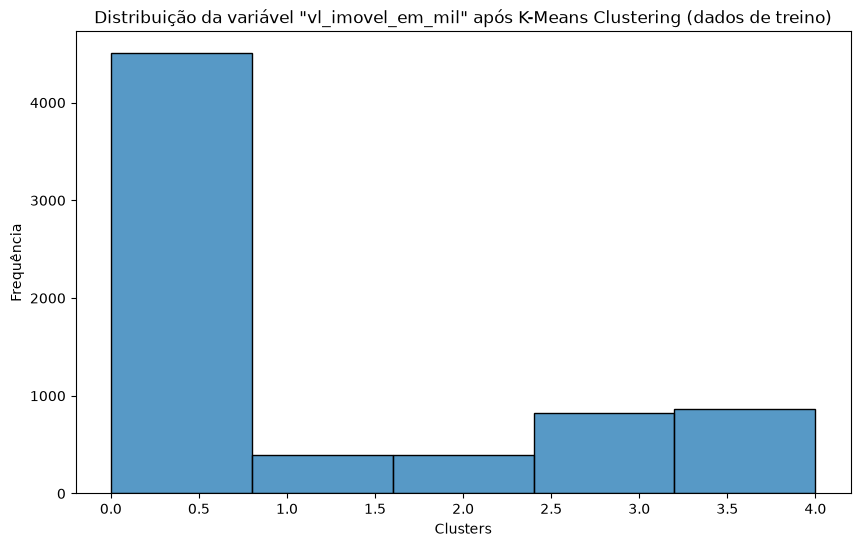

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(X_train['vl_imovel_em_mil_kmeans'], bins=5, kde=False)
plt.title('Distribuição da variável "vl_imovel_em_mil" após K-Means Clustering (dados de treino)')
plt.xlabel('Clusters')
plt.ylabel('Frequência')
plt.show()

Feitas as discreções, vamos iniciar o tratamento das colunas categóricas

# Tratamento de dados categóricos

Para as colunas categóricas, também vamos aplicar diferentes tipos de encoding:

escola — 

estado_civil — 

sexo — K-Means: 

O objetivo é 

# Tratamento de desbalanceamento

# Técnicas utilizadas

Verificação de IDs duplicados e correção - Feito

Outliers por limiar - Feito

Outliers por IQR - Feito

